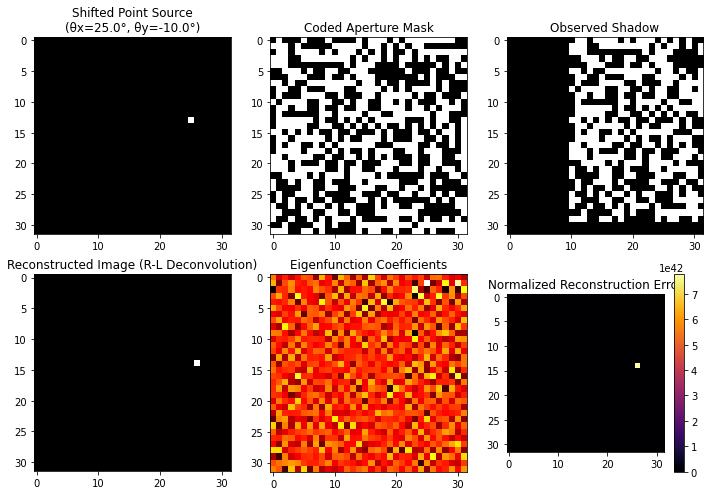

<Figure size 432x288 with 0 Axes>

Reconstruction completed. Light source is at (25, 13).
Original angles used: θₓ = 25.00°, θᵧ = -10.00°
Light source was placed at pixel: (25, 13) due to shifting


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import affine_transform
from scipy.signal import convolve2d

# Increased height to amplify displacement
h = 20  
theta_min = np.arctan(1 / h)

np.random.seed(42)
mask = np.random.choice([0, 1], size=(32, 32))

theta_x_range = np.linspace(-theta_min * 16, theta_min * 16, 32)  
theta_y_range = np.linspace(-theta_min * 16, theta_min * 16, 32)  

shadow_lib = np.zeros((32, 32, 32, 32))  

# Creating a shadow library by shifting the mask based on angle of incidence
for i, theta_x in enumerate(theta_x_range):
    for j, theta_y in enumerate(theta_y_range):
        shift_x = h * np.tan(theta_x)  
        shift_y = h * np.tan(theta_y)

        shadow = mask.copy().astype(float)
        shadow_shifted = affine_transform(shadow, matrix=np.eye(2), offset=(-shift_y, -shift_x), mode='constant')

        shadow_shifted = shadow_shifted / shadow_shifted.max() if shadow_shifted.max() != 0 else shadow_shifted
        shadow_lib[i, j] = shadow_shifted  

# Light source angles (angle of incidence)
true_theta_x = np.deg2rad(25)  # Angle in radians (e.g., 15 degrees)
true_theta_y = np.deg2rad(-10) # Angle in radians (e.g., -20 degrees)

# Calculate the displacement in x and y directions based on the angle of incidence
shift_x = h * np.tan(true_theta_x)
shift_y = h * np.tan(true_theta_y)

# Compute new light source position considering the angle of incidence
center_x, center_y = 16 + int(shift_x), 16 + int(shift_y)

# Ensure the light source stays within the bounds of the image
shifted_source = np.zeros((32, 32))
if 0 <= center_x < 32 and 0 <= center_y < 32:
    shifted_source[center_y, center_x] = 1  

# Generate the observed shadow by convolving the shifted source with the coded mask
observed_shadow = convolve2d(shifted_source, mask.astype(float), mode='same')

# Richardson-Lucy Deconvolution Function
def richardson_lucy_auto_displacement(observed, psf, epsilon=1e-5, max_iter=50):
    F = np.full_like(observed, np.mean(observed))
    for _ in range(max_iter):
        G = convolve2d(F, psf, mode='same', boundary='wrap')
        C = observed / (G + epsilon)
        correction = convolve2d(C, np.flip(psf), mode='same', boundary='wrap')
        F = F * correction
    return F

# Perform Richardson-Lucy deconvolution on the observed shadow
reconstructed_image = richardson_lucy_auto_displacement(observed_shadow, mask, max_iter=200)

# Eigenfunction-based Restoration
def eigen_restore(shadow_lib, observed_shadow):
    shadow_lib_reshaped = shadow_lib.reshape(1024, -1)  # Flattening shadow library
    observed_shadow_flat = observed_shadow.flatten()  # Flatten observed shadow
    coeffs = np.linalg.lstsq(shadow_lib_reshaped, observed_shadow_flat, rcond=None)[0]  # Solving the least squares problem
    return coeffs

# Obtain the eigenfunction coefficients for shadow restoration
coefficients = eigen_restore(shadow_lib.reshape(1024, 32, 32), observed_shadow)

# Plot results to visualize the process
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# Display the shifted source (representing the incident light position)
axes[0, 0].imshow(shifted_source, cmap='gray')
axes[0, 0].set_title(f"Shifted Point Source\n(θx={np.rad2deg(true_theta_x):.1f}°, θy={np.rad2deg(true_theta_y):.1f}°)")

# Display the coded aperture mask
axes[0, 1].imshow(mask, cmap='gray')
axes[0, 1].set_title("Coded Aperture Mask")

# Display the observed shadow after convolving the shifted source with the mask
axes[0, 2].imshow(observed_shadow, cmap='gray')
axes[0, 2].set_title("Observed Shadow")

# Display the reconstructed image after Richardson-Lucy deconvolution
axes[1, 0].imshow(reconstructed_image, cmap='gray')
axes[1, 0].set_title("Reconstructed Image (R-L Deconvolution)")

# Display the eigenfunction coefficients map
coeff_map = coefficients.reshape(32, 32) if coefficients.size == 1024 else np.zeros((32, 32))
axes[1, 1].imshow(coeff_map, cmap='hot', aspect='auto')
axes[1, 1].set_title("Eigenfunction Coefficients")

# Display the error between the original mask and the reconstructed image
# Normalized error for better visualization of small differences
error = np.abs(shifted_source - reconstructed_image)
# Plotting the error
plt.imshow(error, cmap='inferno')
plt.title("Normalized Reconstruction Error")
plt.colorbar()  # Show the color scale for error magnitude
plt.show()


# Show the entire plot
plt.tight_layout()
plt.show()

# Print the results
print(f"Reconstruction completed. Light source is at ({center_x}, {center_y}).")
print(f"Original angles used: θₓ = {np.rad2deg(true_theta_x):.2f}°, θᵧ = {np.rad2deg(true_theta_y):.2f}°")
print(f"Light source was placed at pixel: ({center_x}, {center_y}) due to shifting")


In [9]:
import os
import matplotlib.pyplot as plt
import numpy as np

# Directory to save shadow images
output_folder = "shadow_library_images"
os.makedirs(output_folder, exist_ok=True)  # Create folder if it doesn't exist

# Function to sanitize filename (replace minus with 'm' for consistency)
def sanitize_angle(angle_rad):
    angle_deg = np.rad2deg(angle_rad)
    return f"{angle_deg:.2f}".replace('-', 'm')

# Save each shadow pattern as an image
for i, theta_x in enumerate(theta_x_range):
    for j, theta_y in enumerate(theta_y_range):
        shadow = shadow_lib[i, j]  # Get the shadow pattern

        # Create a filename with sanitized angle values
        theta_x_label = sanitize_angle(theta_x)
        theta_y_label = sanitize_angle(theta_y)
        filename = f"shadow_thetaX_{theta_x_label}_thetaY_{theta_y_label}.png"
        filepath = os.path.join(output_folder, filename)

        # Save the image
        plt.imsave(filepath, shadow, cmap='gray')

        # Optional: Track progress
        print(f"Saved: {filename}")

Saved: shadow_thetaX_m45.80_thetaY_m45.80.png
Saved: shadow_thetaX_m45.80_thetaY_m42.84.png
Saved: shadow_thetaX_m45.80_thetaY_m39.89.png
Saved: shadow_thetaX_m45.80_thetaY_m36.93.png
Saved: shadow_thetaX_m45.80_thetaY_m33.98.png
Saved: shadow_thetaX_m45.80_thetaY_m31.02.png
Saved: shadow_thetaX_m45.80_thetaY_m28.07.png
Saved: shadow_thetaX_m45.80_thetaY_m25.12.png
Saved: shadow_thetaX_m45.80_thetaY_m22.16.png
Saved: shadow_thetaX_m45.80_thetaY_m19.21.png
Saved: shadow_thetaX_m45.80_thetaY_m16.25.png
Saved: shadow_thetaX_m45.80_thetaY_m13.30.png
Saved: shadow_thetaX_m45.80_thetaY_m10.34.png
Saved: shadow_thetaX_m45.80_thetaY_m7.39.png
Saved: shadow_thetaX_m45.80_thetaY_m4.43.png
Saved: shadow_thetaX_m45.80_thetaY_m1.48.png
Saved: shadow_thetaX_m45.80_thetaY_1.48.png
Saved: shadow_thetaX_m45.80_thetaY_4.43.png
Saved: shadow_thetaX_m45.80_thetaY_7.39.png
Saved: shadow_thetaX_m45.80_thetaY_10.34.png
Saved: shadow_thetaX_m45.80_thetaY_13.30.png
Saved: shadow_thetaX_m45.80_thetaY_16.25.png


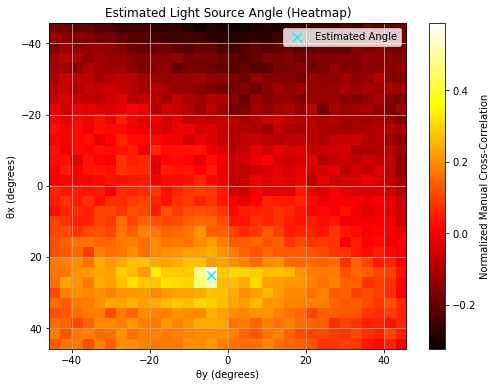

Estimated θₓ = 25.12°, θᵧ = -4.43°


In [12]:
import numpy as np
import matplotlib.pyplot as plt

def estimate_angle_manual_correlation(observed_shadow, shadow_lib, theta_x_range, theta_y_range):
    """
    Estimate the light source angles (theta_x, theta_y) by manually computing the cross-correlation
    between the observed shadow and each pattern in the shadow library.
    """
    correlations = np.zeros((len(theta_x_range), len(theta_y_range)))

    # Normalize the observed shadow
    observed_norm = observed_shadow - np.mean(observed_shadow)
    observed_norm /= (np.linalg.norm(observed_norm) + 1e-8)  # Avoid division by zero

    for i, theta_x in enumerate(theta_x_range):
        for j, theta_y in enumerate(theta_y_range):
            shadow = shadow_lib[i, j]

            # Normalize shadow pattern
            shadow_norm = shadow - np.mean(shadow)
            shadow_norm /= (np.linalg.norm(shadow_norm) + 1e-8)

            # Compute dot product (manual correlation)
            correlation = np.sum(observed_norm * shadow_norm)
            correlations[i, j] = correlation

    # Find the angle with the highest correlation
    max_idx = np.unravel_index(np.argmax(correlations), correlations.shape)
    est_theta_x = theta_x_range[max_idx[0]]
    est_theta_y = theta_y_range[max_idx[1]]

    # Plot correlation heatmap
    plt.figure(figsize=(8, 6))
    plt.imshow(correlations, extent=[
        np.rad2deg(theta_y_range[0]), np.rad2deg(theta_y_range[-1]),
        np.rad2deg(theta_x_range[-1]), np.rad2deg(theta_x_range[0])
    ], cmap='hot', aspect='auto')
    plt.colorbar(label='Normalized Manual Cross-Correlation')
    plt.title("Estimated Light Source Angle (Heatmap)")
    plt.xlabel("θy (degrees)")
    plt.ylabel("θx (degrees)")
    plt.scatter(np.rad2deg(est_theta_y), np.rad2deg(est_theta_x), color='cyan', s=80, marker='x', label="Estimated Angle")
    plt.legend()
    plt.grid(True)
    plt.show()

    return est_theta_x, est_theta_y

estimated_theta_x, estimated_theta_y = estimate_angle_manual_correlation(
    observed_shadow, shadow_lib, theta_x_range, theta_y_range
)

print(f"Estimated θₓ = {np.rad2deg(estimated_theta_x):.2f}°, θᵧ = {np.rad2deg(estimated_theta_y):.2f}°")


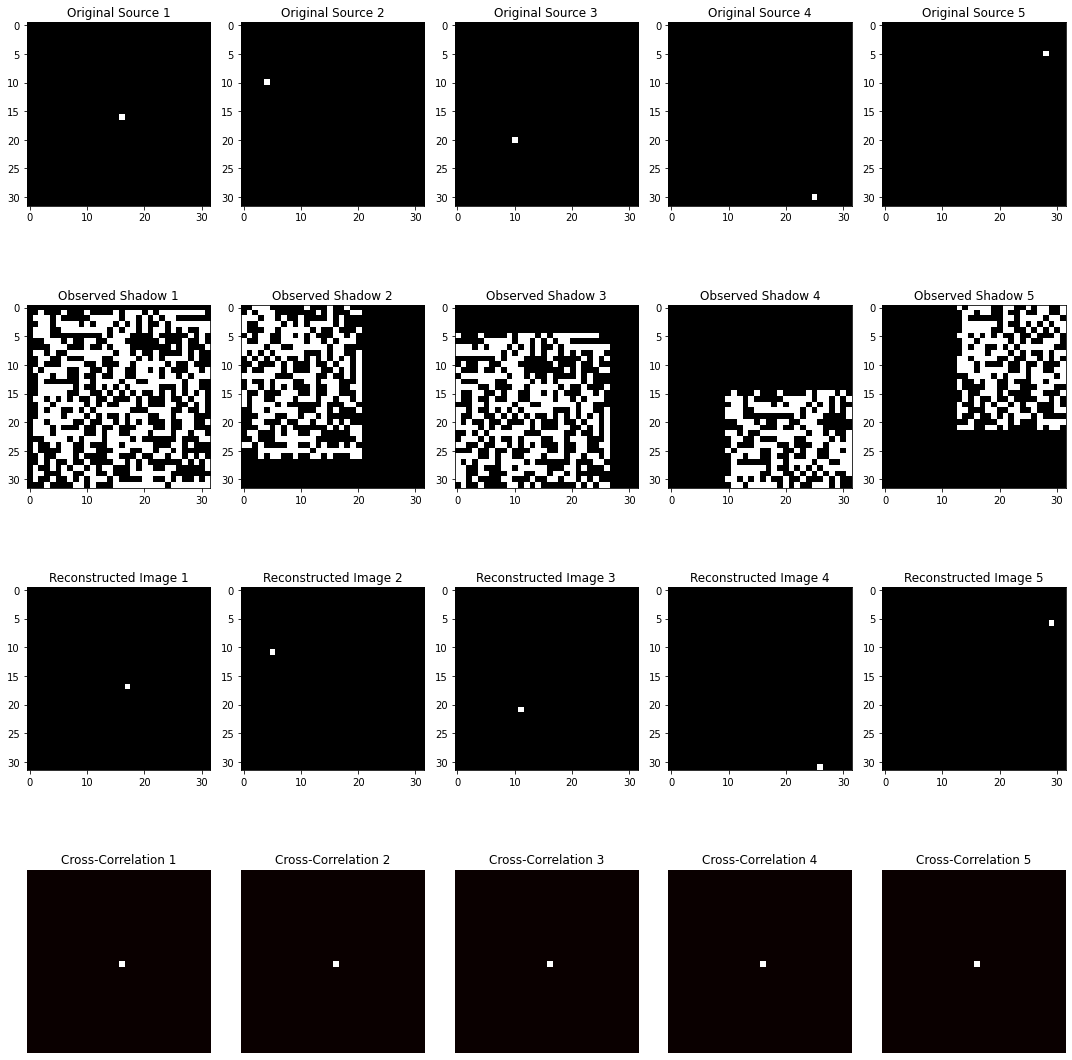

Source 1 was at (16, 16).
Source 2 was at (4, 10).
Source 3 was at (10, 20).
Source 4 was at (25, 30).
Source 5 was at (28, 5).


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import affine_transform
from scipy.signal import convolve2d, correlate2d

# Increased height to amplify displacement
h = 20  
theta_min = np.arctan(1 / h)

np.random.seed(42)
mask = np.random.choice([0, 1], size=(32, 32))

theta_x_range = np.linspace(-theta_min * 16, theta_min * 16, 32)  
theta_y_range = np.linspace(-theta_min * 16, theta_min * 16, 32)  

shadow_lib = np.zeros((32, 32, 32, 32))  

# Creating a shadow library by shifting the mask based on angle of incidence
for i, theta_x in enumerate(theta_x_range):
    for j, theta_y in enumerate(theta_y_range):
        shift_x = h * np.tan(theta_x)  
        shift_y = h * np.tan(theta_y)

        shadow = mask.copy().astype(float)
        shadow_shifted = affine_transform(shadow, matrix=np.eye(2), offset=(-shift_y, -shift_x), mode='constant')

        shadow_shifted = shadow_shifted / shadow_shifted.max() if shadow_shifted.max() != 0 else shadow_shifted
        shadow_lib[i, j] = shadow_shifted  

# Define 5 different source positions
source_positions = [(16, 16),   # Center position
                    (4, 10), 
                    (10, 20), 
                    (25, 30), 
                    (28, 5)]

# Create the observed shadow for each source position
observed_shadows = []
original_sources = []  # Store original source images
for pos in source_positions:
    shifted_source = np.zeros((32, 32))
    shifted_source[pos[1], pos[0]] = 1  # Set a light source at each location
    observed_shadow = convolve2d(shifted_source, mask.astype(float), mode='same')
    observed_shadows.append(observed_shadow)
    original_sources.append(shifted_source)  # Store the original source

# Richardson-Lucy Deconvolution Function
def richardson_lucy_auto_displacement(observed, psf, epsilon=1e-5, max_iter=50):
    F = np.full_like(observed, np.mean(observed))
    for _ in range(max_iter):
        G = convolve2d(F, psf, mode='same', boundary='wrap')
        C = observed / (G + epsilon)
        correction = convolve2d(C, np.flip(psf), mode='same', boundary='wrap')
        F = F * correction
    return F

# Plot and cross-correlate the results for each source position
fig, axes = plt.subplots(4, 5, figsize=(15, 16))  # Adjusted for 4 rows of plots

for i, observed_shadow in enumerate(observed_shadows):
    # Perform Richardson-Lucy deconvolution on the observed shadow
    reconstructed_image = richardson_lucy_auto_displacement(observed_shadow, mask, max_iter=200)
    
    # Plot the original source image
    axes[0, i].imshow(original_sources[i], cmap='gray')
    axes[0, i].set_title(f"Original Source {i+1}")
    
    # Plot the observed shadow
    axes[1, i].imshow(observed_shadow, cmap='gray')
    axes[1, i].set_title(f"Observed Shadow {i+1}")
    
    # Plot the reconstructed image after Richardson-Lucy deconvolution
    axes[2, i].imshow(reconstructed_image, cmap='gray')
    axes[2, i].set_title(f"Reconstructed Image {i+1}")
    
    # Compute cross-correlation between the reconstructed image and shifted source (without centering)
    shifted_source = np.zeros((32, 32))
    shifted_source[source_positions[i][1], source_positions[i][0]] = 1  # Set the original source location
    cross_corr = correlate2d(reconstructed_image, shifted_source, mode='same')  # Using 'same' for visibility
    
    # Normalize cross-correlation for better visualization
    cross_corr = (cross_corr - np.min(cross_corr)) / (np.max(cross_corr) - np.min(cross_corr))  # Normalize to [0, 1]
    
    # Plot the cross-correlation result
    axes[3, i].imshow(cross_corr, cmap='hot')
    axes[3, i].set_title(f"Cross-Correlation {i+1}")
    axes[3, i].axis('off')

# Adjust layout and display the plots
plt.tight_layout()
plt.show()

# Print results
for i, pos in enumerate(source_positions):
    print(f"Source {i+1} was at {pos}.")

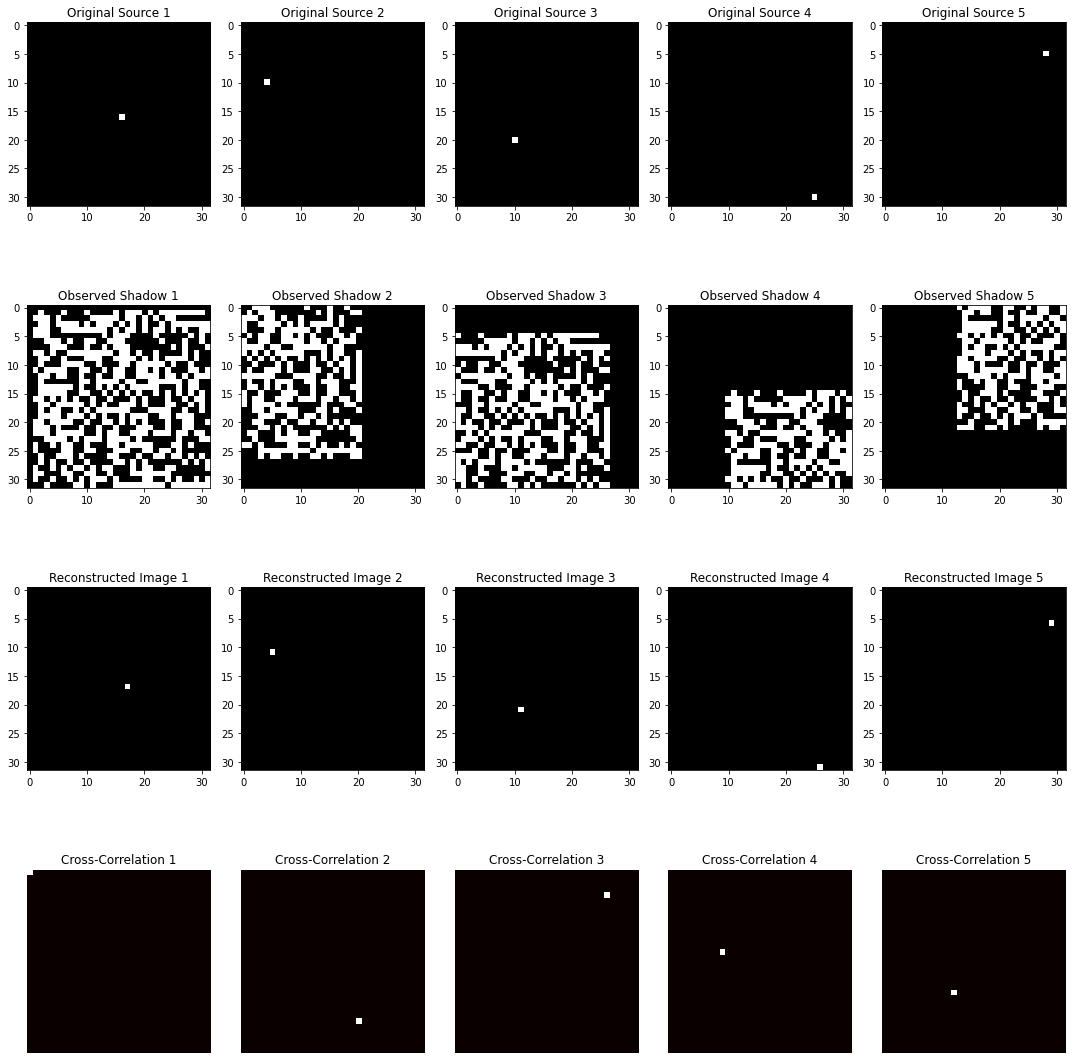

Source 1 was at (16, 16).
Source 2 was at (4, 10).
Source 3 was at (10, 20).
Source 4 was at (25, 30).
Source 5 was at (28, 5).


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import affine_transform
from scipy.signal import convolve2d, correlate2d

# Increased height to amplify displacement
h = 20  
theta_min = np.arctan(1 / h)

np.random.seed(42)
mask = np.random.choice([0, 1], size=(32, 32))

theta_x_range = np.linspace(-theta_min * 16, theta_min * 16, 32)  
theta_y_range = np.linspace(-theta_min * 16, theta_min * 16, 32)  

shadow_lib = np.zeros((32, 32, 32, 32))  

# Creating a shadow library by shifting the mask based on angle of incidence
for i, theta_x in enumerate(theta_x_range):
    for j, theta_y in enumerate(theta_y_range):
        shift_x = h * np.tan(theta_x)  
        shift_y = h * np.tan(theta_y)

        shadow = mask.copy().astype(float)
        shadow_shifted = affine_transform(shadow, matrix=np.eye(2), offset=(shift_y, shift_x), mode='constant')

        shadow_shifted = shadow_shifted / shadow_shifted.max() if shadow_shifted.max() != 0 else shadow_shifted
        shadow_lib[i, j] = shadow_shifted  

# Define 5 different source positions
source_positions = [(16, 16),   # Center position
                    (4, 10), 
                    (10, 20), 
                    (25, 30), 
                    (28, 5)]

# Create the observed shadow for each source position
observed_shadows = []
original_sources = []  # Store original source images
for pos in source_positions:
    shifted_source = np.zeros((32, 32))
    shifted_source[pos[1], pos[0]] = 1  # Set a light source at each location
    observed_shadow = convolve2d(shifted_source, mask.astype(float), mode='same')
    observed_shadows.append(observed_shadow)
    original_sources.append(shifted_source)  # Store the original source

# Richardson-Lucy Deconvolution Function
def richardson_lucy_auto_displacement(observed, psf, epsilon=1e-5, max_iter=50):
    F = np.full_like(observed, np.mean(observed))
    for _ in range(max_iter):
        G = convolve2d(F, psf, mode='same', boundary='wrap')
        C = observed / (G + epsilon)
        correction = convolve2d(C, np.flip(psf), mode='same', boundary='wrap')
        F = F * correction
    return F

# Plot and cross-correlate the results for each source position
fig, axes = plt.subplots(4, 5, figsize=(15, 16))  # Adjusted for 4 rows of plots

for i, observed_shadow in enumerate(observed_shadows):
    # Perform Richardson-Lucy deconvolution on the observed shadow
    reconstructed_image = richardson_lucy_auto_displacement(observed_shadow, mask, max_iter=200)
    
    # Plot the original source image
    axes[0, i].imshow(original_sources[i], cmap='gray')
    axes[0, i].set_title(f"Original Source {i+1}")
    
    # Plot the observed shadow
    axes[1, i].imshow(observed_shadow, cmap='gray')
    axes[1, i].set_title(f"Observed Shadow {i+1}")
    
    # Plot the reconstructed image after Richardson-Lucy deconvolution
    axes[2, i].imshow(reconstructed_image, cmap='gray')
    axes[2, i].set_title(f"Reconstructed Image {i+1}")
    
    # Compute cross-correlation between the reconstructed image and shifted source (without centering)
    shifted_source = np.zeros((32, 32))
    shifted_source[source_positions[i][1], source_positions[i][0]] = 1  # Set the original source location
    cross_corr = correlate2d(reconstructed_image, shifted_source, mode='same')  # Using 'same' for visibility
    
    # Manually remove centering: calculate the displacement
    shift_x, shift_y = source_positions[i]
    cross_corr_shifted = np.roll(cross_corr, shift=(shift_y, shift_x), axis=(0, 1))
    
    # Normalize cross-correlation for better visualization
    cross_corr_shifted = (cross_corr_shifted - np.min(cross_corr_shifted)) / (np.max(cross_corr_shifted) - np.min(cross_corr_shifted))  # Normalize to [0, 1]
    
    # Plot the cross-correlation result without centering
    axes[3, i].imshow(cross_corr_shifted, cmap='hot')
    axes[3, i].set_title(f"Cross-Correlation {i+1}")
    axes[3, i].axis('off')

# Adjust layout and display the plots
plt.tight_layout()
plt.show()

# Print results
for i, pos in enumerate(source_positions):
    print(f"Source {i+1} was at {pos}.")


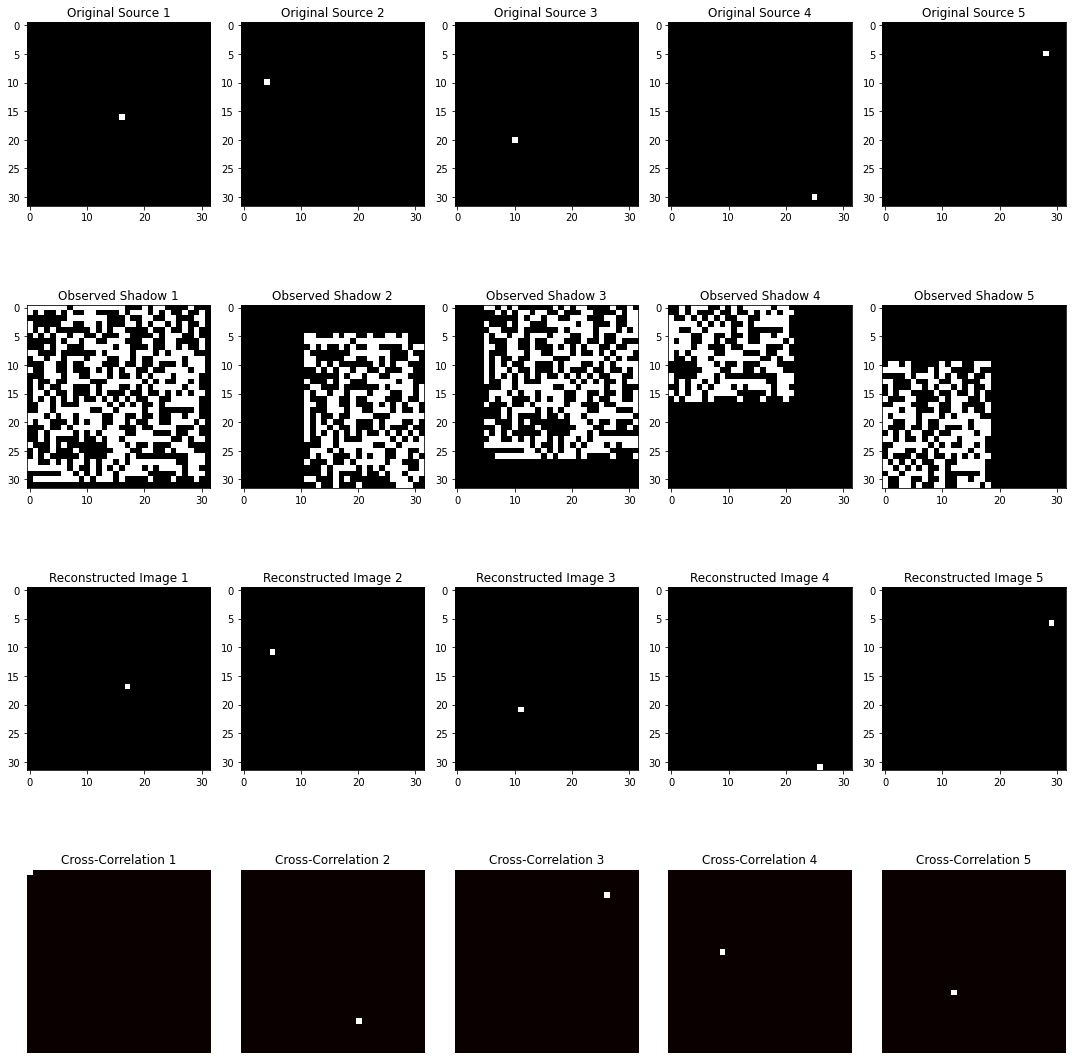

Source 1 was at (16, 16).
Source 2 was at (4, 10).
Source 3 was at (10, 20).
Source 4 was at (25, 30).
Source 5 was at (28, 5).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import affine_transform
from scipy.signal import convolve2d, correlate2d

# Increased height to amplify displacement
h = 20  
theta_min = np.arctan(1 / h)

np.random.seed(42)
mask = np.random.choice([0, 1], size=(32, 32))

# Define angle ranges
theta_x_range = np.linspace(-theta_min * 16, theta_min * 16, 32)  
theta_y_range = np.linspace(-theta_min * 16, theta_min * 16, 32)  

shadow_lib = np.zeros((32, 32, 32, 32))  

# Create shadow library by simulating the correct shadow displacement direction
for i, theta_x in enumerate(theta_x_range):
    for j, theta_y in enumerate(theta_y_range):
        shift_x = h * np.tan(theta_x)  
        shift_y = h * np.tan(theta_y)

        shadow = mask.copy().astype(float)

        # Flip direction: shadow moves opposite to light source direction
        shadow_shifted = affine_transform(
            shadow, matrix=np.eye(2), offset=(-shift_y, -shift_x), mode='constant'
        )

        shadow_shifted = shadow_shifted / shadow_shifted.max() if shadow_shifted.max() != 0 else shadow_shifted
        shadow_lib[i, j] = shadow_shifted  

# Define 5 source positions
source_positions = [(16, 16), (4, 10), (10, 20), (25, 30), (28, 5)]

# Create observed shadows
observed_shadows = []
original_sources = []
for pos in source_positions:
    shifted_source = np.zeros((32, 32))
    shifted_source[pos[1], pos[0]] = 1  # (x, y) = (col, row)
    observed_shadow = convolve2d(shifted_source, mask.astype(float), mode='same')
    observed_shadows.append(observed_shadow)
    original_sources.append(shifted_source)

# Richardson-Lucy Deconvolution
def richardson_lucy_auto_displacement(observed, psf, epsilon=1e-5, max_iter=50):
    F = np.full_like(observed, np.mean(observed))
    for _ in range(max_iter):
        G = convolve2d(F, psf, mode='same', boundary='wrap')
        C = observed / (G + epsilon)
        correction = convolve2d(C, np.flip(psf), mode='same', boundary='wrap')
        F = F * correction
    return F

# Plot and analyze
fig, axes = plt.subplots(4, 5, figsize=(15, 16))

for i, observed_shadow in enumerate(observed_shadows):
    reconstructed_image = richardson_lucy_auto_displacement(observed_shadow, mask, max_iter=200)

    # Row 1: Original source
    axes[0, i].imshow(original_sources[i], cmap='gray')
    axes[0, i].set_title(f"Original Source {i+1}")

    # Row 2: Observed shadow
    axes[1, i].imshow(np.rot90(observed_shadow, 2), cmap='gray')  # Rotates 180 degrees
    axes[1, i].set_title(f"Observed Shadow {i+1}")

    # Row 3: Reconstructed image
    axes[2, i].imshow(reconstructed_image, cmap='gray')
    axes[2, i].set_title(f"Reconstructed Image {i+1}")

    # Row 4: Cross-correlation (without centering)
    shifted_source = np.zeros((32, 32))
    shifted_source[source_positions[i][1], source_positions[i][0]] = 1
    cross_corr = correlate2d(reconstructed_image, shifted_source, mode='same')
    
    # Roll manually by source location (if needed)
    shift_x, shift_y = source_positions[i]
    cross_corr_shifted = np.roll(cross_corr, shift=(shift_y, shift_x), axis=(0, 1))

    # Normalize for display
    cross_corr_shifted = (cross_corr_shifted - np.min(cross_corr_shifted)) / (np.max(cross_corr_shifted) - np.min(cross_corr_shifted))
    
    axes[3, i].imshow(cross_corr_shifted, cmap='hot')
    axes[3, i].set_title(f"Cross-Correlation {i+1}")
    axes[3, i].axis('off')

plt.tight_layout()
plt.show()

# Print actual source positions
for i, pos in enumerate(source_positions):
    print(f"Source {i+1} was at {pos}.")